# 02 · Feature Engineering — RFM + Advanced Features
**Input**: `data/processed/online_retail_clean.parquet`  
**Output**: `data/processed/rfm_features.csv` · `data/processed/rfm_scaled.csv`

---
## Why RFM?
RFM (Recency · Frequency · Monetary) is the industry-standard framework for  
behavioural customer profiling.  Every major CRM and marketing platform uses it  
because it captures the three dimensions that predict future purchase intent.

| Feature | Question answered | Signal |
|---------|------------------|--------|
| **Recency** | How recently did they buy? | Engagement freshness |
| **Frequency** | How often do they buy? | Habit & loyalty |
| **Monetary** | How much do they spend? | Economic value |

We extend this with 8 additional behavioural features to give the clustering  
algorithm richer signal beyond the raw RFM triad.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.float_format', '{:,.2f}'.format)

from pathlib import Path
PROC_DIR = Path('../data/processed')
PLOT_DIR = Path('../docs/eda_plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROC_DIR / 'online_retail_clean.parquet')
print(f'Loaded: {df.shape[0]:,} rows · {df.CustomerID.nunique():,} customers')
df.head(2)


Loaded: 46,588 rows · 3,155 customers


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,DayOfWeek,Hour,IsWeekend,TotalRevenue
0,4977,57391,Product 52663,38,2011-05-04 05:00:00,18.95,10858,United Kingdom,2011,5,Wednesday,5,False,720.10
1,5717,35553,Product 78376,5,2011-01-07 22:00:00,27.51,12180,Portugal,2011,1,Friday,22,False,137.55


## 2. Snapshot date
Using **one day after the last transaction** as the reference point for Recency calculations — a standard industry convention.

In [2]:
SNAPSHOT = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {SNAPSHOT.date()}')
print(f'(Last transaction: {df.InvoiceDate.max().date()})')


Snapshot date: 2011-12-10
(Last transaction: 2011-12-09)


## 3. Core RFM aggregation

In [3]:
rfm = (
    df.groupby('CustomerID')
    .agg(
        LastPurchase  = ('InvoiceDate',  'max'),
        Frequency     = ('InvoiceNo',    'nunique'),   # unique orders
        Monetary      = ('TotalRevenue', 'sum'),        # total spend £
    )
    .reset_index()
)

rfm['Recency'] = (SNAPSHOT - rfm['LastPurchase']).dt.days
rfm = rfm.drop(columns='LastPurchase')

print(rfm[['Recency','Frequency','Monetary']].describe().round(2).to_string())


       Recency  Frequency   Monetary
count 3,155.00   3,155.00   3,155.00
mean     29.03      14.70  22,649.59
std      30.32       7.41  13,330.11
min       1.00       3.00   1,488.57
25%       8.00      10.00  14,058.78
50%      19.00      13.00  19,520.93
75%      39.00      17.00  27,835.50
max     244.00      87.00 131,852.73


## 4. Advanced behavioural features

In [4]:
# ── Tenure: days from first to last purchase ─────────────────────────────
tenure = (
    df.groupby('CustomerID')['InvoiceDate']
    .agg(first='min', last='max')
    .assign(TenureDays=lambda x: (x['last'] - x['first']).dt.days.clip(lower=1))
    ['TenureDays']
)
rfm = rfm.join(tenure, on='CustomerID')

# ── Average Order Value ───────────────────────────────────────────────────
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# ── Purchase Frequency per month ──────────────────────────────────────────
rfm['ActiveMonths'] = (rfm['TenureDays'] / 30.44).clip(lower=1)
rfm['PurchaseFreqMonthly'] = rfm['Frequency'] / rfm['ActiveMonths']
rfm = rfm.drop(columns='ActiveMonths')

# ── Customer Lifetime Value (proxy) ───────────────────────────────────────
rfm['CLV'] = rfm['AvgOrderValue'] * rfm['PurchaseFreqMonthly'] * 12

# ── Unique products purchased ─────────────────────────────────────────────
unique_prods = df.groupby('CustomerID')['StockCode'].nunique().rename('UniqueProducts')
rfm = rfm.join(unique_prods, on='CustomerID')

# ── Average basket size (items per invoice) ───────────────────────────────
basket = (
    df.groupby(['CustomerID','InvoiceNo'])['Quantity'].sum()
    .groupby('CustomerID').mean()
    .rename('AvgBasketSize')
)
rfm = rfm.join(basket, on='CustomerID')

# ── Monthly spend coefficient of variation (consistency) ─────────────────
monthly_spend = (
    df.groupby(['CustomerID', df['InvoiceDate'].dt.to_period('M')])['TotalRevenue']
    .sum()
    .reset_index()
)
monthly_cv = (
    monthly_spend.groupby('CustomerID')['TotalRevenue']
    .agg(lambda x: x.std() / x.mean() if x.mean() > 0 else 0)
    .rename('MonthlySpendCV')
)
rfm = rfm.join(monthly_cv, on='CustomerID')

# ── Weekend shopper ratio ─────────────────────────────────────────────────
wsr = df.groupby('CustomerID')['IsWeekend'].mean().rename('WeekendShopperRatio')
rfm = rfm.join(wsr, on='CustomerID')

# ── Fill any NaNs from joins ──────────────────────────────────────────────
rfm = rfm.set_index('CustomerID')
rfm = rfm.fillna(rfm.median(numeric_only=True))

print(f'Feature matrix: {rfm.shape[0]:,} customers × {rfm.shape[1]} features')
rfm.head(3)


Feature matrix: 3,155 customers × 11 features


,Frequency,Monetary,Recency,TenureDays,AvgOrderValue,PurchaseFreqMonthly,CLV,UniqueProducts,AvgBasketSize,MonthlySpendCV,WeekendShopperRatio
CustomerID,,,,,,,,,,,
10004,27,"46,681.57",18,346,"1,728.95",2.38,"49,282.79",27,59.52,0.80,0.22
10008,16,"29,354.16",2,347,"1,834.63",1.40,"30,900.54",16,58.00,0.52,0.44
10009,26,"38,995.22",16,353,"1,499.82",2.24,"40,351.77",26,56.54,0.73,0.31


## 5. RFM quartile scoring (1 = worst, 4 = best)

In [5]:
def safe_qcut(series, q=4, ascending=True):
    """qcut that gracefully handles duplicate bin edges on small datasets."""
    try:
        cut = pd.qcut(series, q=q, duplicates='drop', retbins=False)
        n_bins = cut.cat.categories.nunique()
        labels = list(range(1, n_bins+1)) if ascending else list(range(n_bins, 0, -1))
        return pd.qcut(series, q=q, labels=labels, duplicates='drop').astype(int)
    except Exception:
        ranked = series.rank(method='first', ascending=ascending)
        return pd.cut(ranked, bins=q, labels=range(1,q+1), include_lowest=True).astype(int)

# Recency: lower days = better → score reversed
rfm['R_Score'] = safe_qcut(rfm['Recency'],   q=4, ascending=False)
rfm['F_Score'] = safe_qcut(rfm['Frequency'], q=4, ascending=True)
rfm['M_Score'] = safe_qcut(rfm['Monetary'],  q=4, ascending=True)

rfm['RFM_Score']   = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm['RF_Segment']  = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

print(rfm[['R_Score','F_Score','M_Score','RFM_Score']].describe().round(2).to_string())


       R_Score  F_Score  M_Score  RFM_Score
count 3,155.00 3,155.00 3,155.00   3,155.00
mean      2.52     2.37     2.50       7.39
std       1.13     1.15     1.12       2.75
min       1.00     1.00     1.00       3.00
25%       2.00     1.00     1.50       5.00
50%       3.00     2.00     2.00       7.00
75%       4.00     3.00     3.50      10.00
max       4.00     4.00     4.00      12.00


## 6. Named RFM segment labels

In [6]:
import re

SEGMENT_MAP = {
    r'[3-4][3-4]': 'Champions',
    r'[2-3][3-4]': 'Loyal Customers',
    r'[3-4][1-2]': 'Potential Loyalists',
    r'4[0-2]':     'Recent Customers',
    r'3[0-2]':     'Promising',
    r'2[1-2]':     'Needs Attention',
    r'[0-1][1-3]': 'At Risk',
    r'[0-1][4]':   'Cannot Lose Them',
    r'1[1-2]':     'Hibernating',
    r'[0-1][0-1]': 'Lost',
}

def map_segment(rf):
    for pattern, label in SEGMENT_MAP.items():
        if re.match(pattern, str(rf)):
            return label
    return 'Other'

rfm['RFM_Segment'] = rfm['RF_Segment'].apply(map_segment)

dist = rfm['RFM_Segment'].value_counts()
print(dist.to_string())


RFM_Segment
Champions              906
At Risk                726
Potential Loyalists    686
Needs Attention        490
Loyal Customers        299
Cannot Lose Them        48


## 7. Scale features for clustering
`RobustScaler` — uses median + IQR. Resistant to the extreme spend outliers typical in retail data.

In [7]:
# Features used for clustering (numeric behavioural features only)
MODEL_FEATURES = [
    'Recency', 'Frequency', 'Monetary',
    'AvgOrderValue', 'TenureDays', 'CLV',
    'UniqueProducts', 'AvgBasketSize',
    'PurchaseFreqMonthly', 'MonthlySpendCV', 'WeekendShopperRatio',
]

scaler  = RobustScaler()
X_arr   = scaler.fit_transform(rfm[MODEL_FEATURES])
X_scaled = pd.DataFrame(X_arr, index=rfm.index, columns=MODEL_FEATURES)

print(f'Scaled matrix: {X_scaled.shape}')
print('\nPost-scaling stats (should be centred near 0):')
X_scaled.describe().loc[['mean','std']].round(3)


Scaled matrix: (3155, 11)

Post-scaling stats (should be centred near 0):


,Recency,Frequency,Monetary,AvgOrderValue,TenureDays,CLV,UniqueProducts,AvgBasketSize,PurchaseFreqMonthly,MonthlySpendCV,WeekendShopperRatio
mean,0.32,0.24,0.23,0.08,-0.21,0.20,0.25,0.01,0.23,0.08,0.05
std,0.98,1.06,0.97,1.14,0.83,0.98,1.07,0.77,0.95,0.83,0.82


## 8. Feature distribution plots

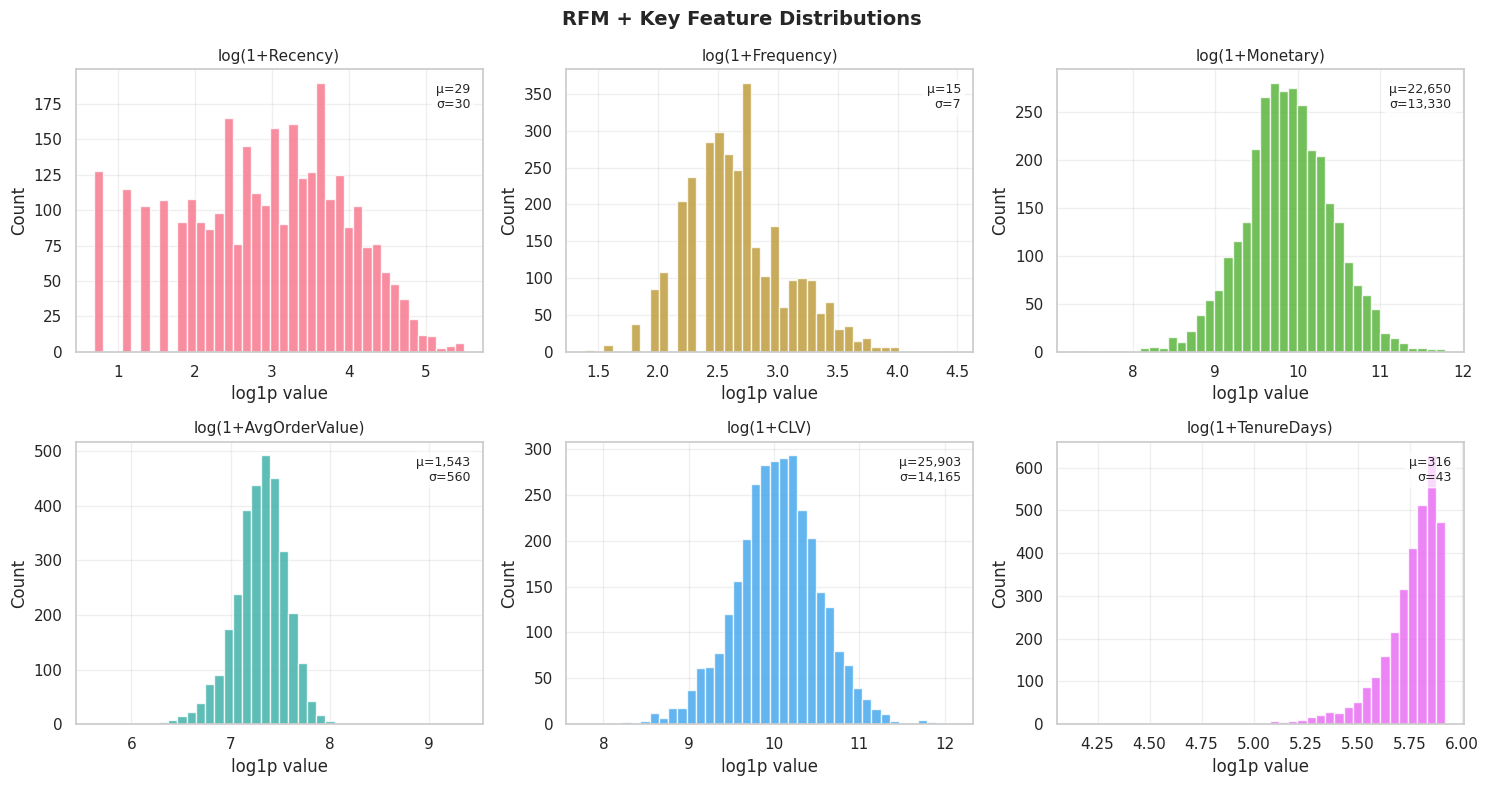

Plot saved ✓


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('RFM + Key Feature Distributions', fontsize=14, fontweight='bold')
axes = axes.flatten()

cols_to_plot = ['Recency', 'Frequency', 'Monetary',
                'AvgOrderValue', 'CLV', 'TenureDays']
colors = sns.color_palette('husl', 6)

for ax, col, c in zip(axes, cols_to_plot, colors):
    data = rfm[col].dropna()
    ax.hist(np.log1p(data), bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(f'log(1+{col})', fontsize=11)
    ax.set_xlabel('log1p value')
    ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'μ={data.mean():,.0f}\nσ={data.std():,.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '10_feature_distributions.png', dpi=150)
plt.show()
print('Plot saved ✓')


## 9. Correlation heatmap

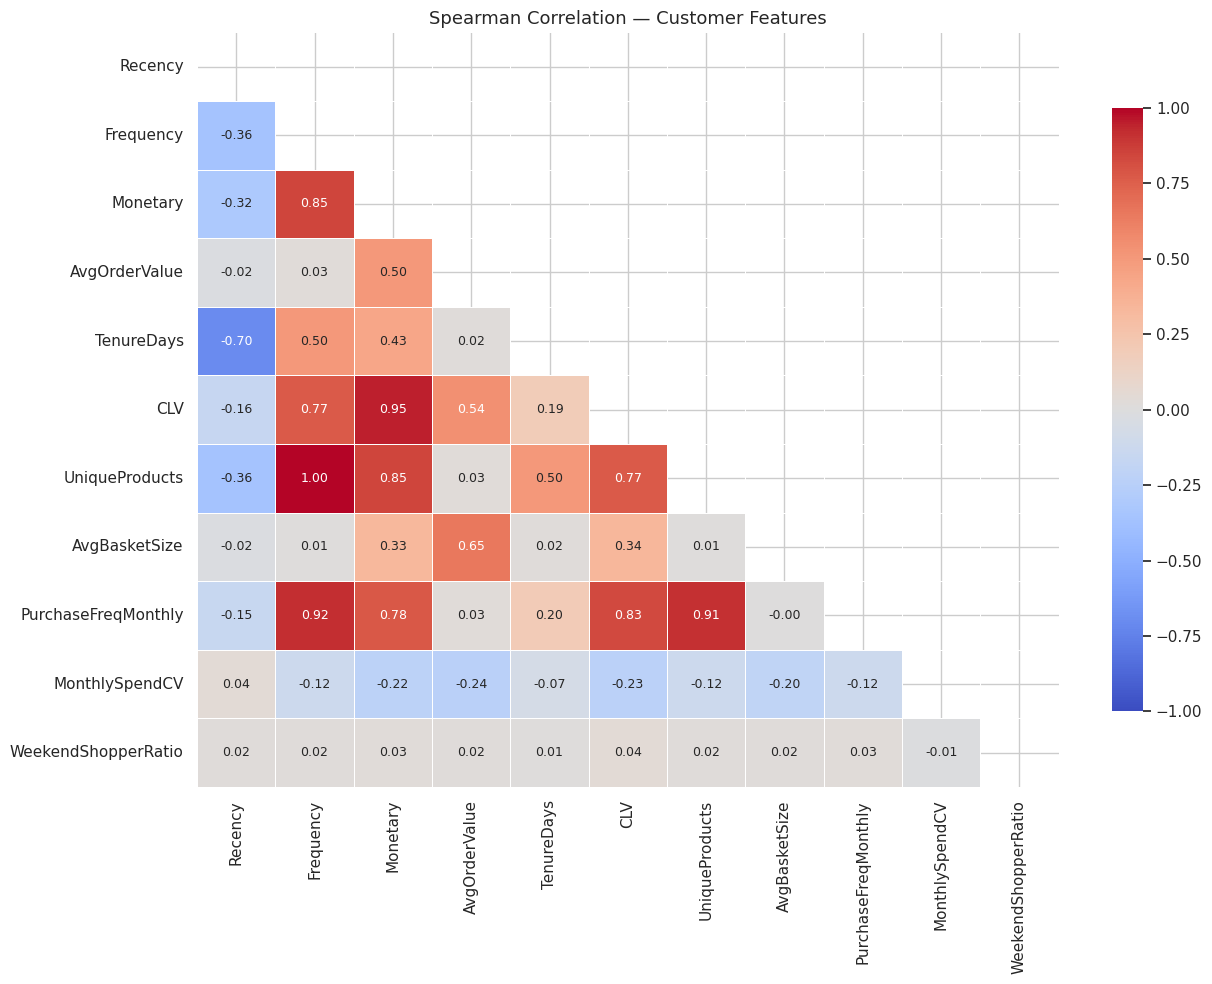


Highest positive correlations:
Frequency       UniqueProducts        1.00
Monetary        CLV                   0.95
Frequency       PurchaseFreqMonthly   0.92
UniqueProducts  PurchaseFreqMonthly   0.91
Frequency       Monetary              0.85


In [9]:
corr = rfm[MODEL_FEATURES].corr(method='spearman').round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, ax=ax,
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.4, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Spearman Correlation — Customer Features', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / '11_correlation_heatmap.png', dpi=150)
plt.show()
print('\nHighest positive correlations:')
corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack().sort_values(ascending=False))
print(corr_pairs.head(5).to_string())


## 10. RFM Segment distribution

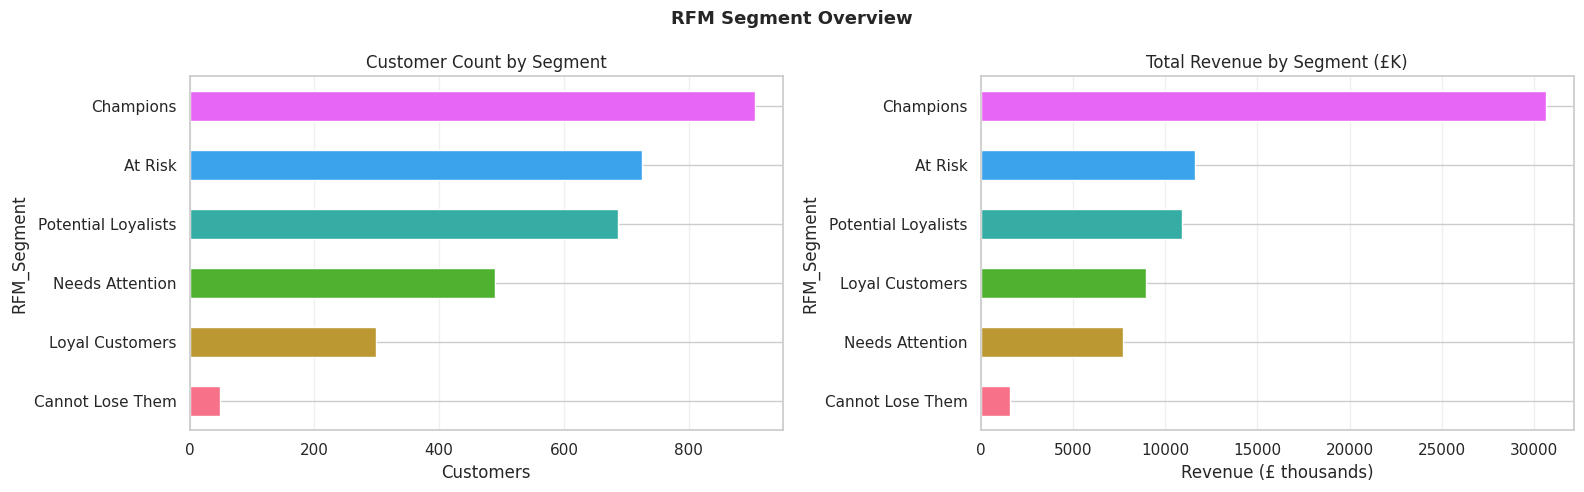

In [10]:
seg_rev = rfm.groupby('RFM_Segment')['Monetary'].sum().sort_values(ascending=False)
seg_cnt = rfm['RFM_Segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('RFM Segment Overview', fontsize=13, fontweight='bold')

colors = sns.color_palette('husl', len(seg_cnt))
seg_cnt.sort_values(ascending=True).plot.barh(ax=axes[0], color=colors)
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Customers')

(seg_rev / 1e3).sort_values(ascending=True).plot.barh(ax=axes[1], color=colors)
axes[1].set_title('Total Revenue by Segment (£K)')
axes[1].set_xlabel('Revenue (£ thousands)')

for ax in axes:
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '12_rfm_segments.png', dpi=150)
plt.show()


## 11. Save features

In [11]:
import joblib

rfm.to_csv(PROC_DIR / 'rfm_features.csv')
X_scaled.to_csv(PROC_DIR / 'rfm_scaled.csv')
joblib.dump(scaler,        '../models/scaler.pkl')
joblib.dump(MODEL_FEATURES,'../models/feature_names.pkl')

print('Saved:')
for f in ['rfm_features.csv', 'rfm_scaled.csv']:
    print(f'  data/processed/{f}')
print('  models/scaler.pkl')
print('  models/feature_names.pkl')
print(f'\nCustomers: {len(rfm):,} | Features for clustering: {len(MODEL_FEATURES)}')
print(f'Features: {MODEL_FEATURES}')


Saved:
  data/processed/rfm_features.csv
  data/processed/rfm_scaled.csv
  models/scaler.pkl
  models/feature_names.pkl

Customers: 3,155 | Features for clustering: 11
Features: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TenureDays', 'CLV', 'UniqueProducts', 'AvgBasketSize', 'PurchaseFreqMonthly', 'MonthlySpendCV', 'WeekendShopperRatio']
